In [184]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import pipeline

# Initialize the object detection pipeline
od_pipe = pipeline(
    task="object-detection",
    model="facebook/detr-resnet-50",
    threshold=0.3
)

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


In [185]:

def process_image(image_path):
    def load_image_from_path(image_path):
        return Image.open(image_path)

    def render_results_in_image(image, results):
        draw = ImageDraw.Draw(image)
        for result in results:
            box = result['box']
            label = result['label']
            score = result['score']
            draw.rectangle([(box['xmin'], box['ymin']), (box['xmax'], box['ymax'])], outline="red", width=3)
            draw.text((box['xmin'], box['ymin']), f"{label} ({score:.2f})", fill="red")
        return image

    def get_cropped_objects(image, results):
        return [(
            image.crop((r['box']['xmin'], r['box']['ymin'], r['box']['xmax'], r['box']['ymax'])),
            r['label'],
            r['score']
        ) for r in results]

    # Load and process image
    raw_image = load_image_from_path(image_path).resize((400, 600))

    # Detect objects
    pipeline_output = od_pipe(raw_image)

    # Filter out objects that are not fully visible
    image_width, image_height = raw_image.size
    fully_visible_objects = [
        result for result in pipeline_output
        if result['box']['xmin'] > 0 and result['box']['ymin'] > 0
           and result['box']['xmax'] < image_width and result['box']['ymax'] < image_height
    ]

    # Create figure for main image
    plt.figure(figsize=(12, 6))
    plt.imshow(render_results_in_image(raw_image.copy(), fully_visible_objects))
    plt.axis('off')
    plt.show()

    # Crop and display detected objects
    cropped_objects = get_cropped_objects(raw_image, fully_visible_objects)

    # Sort cropped objects by size (width * height)
    cropped_objects.sort(key=lambda x: x[0].width * x[0].height, reverse=True)

    # Display cropped objects in a grid
    if cropped_objects:
        cols = 4
        rows = (len(cropped_objects) + cols - 1) // cols
        plt.figure(figsize=(16, 4 * rows))

        for i, (cropped_img, label, score) in enumerate(cropped_objects, 1):
            plt.subplot(rows, cols, i)
            plt.imshow(cropped_img)
            plt.title(f"{label}\n({score:.2f})")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

# Example usage

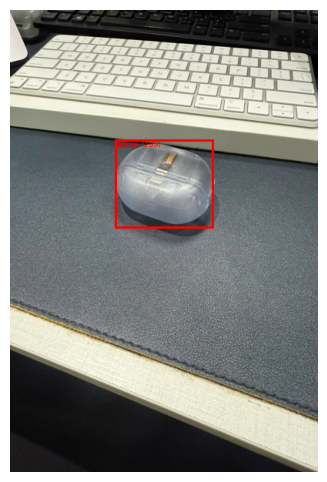

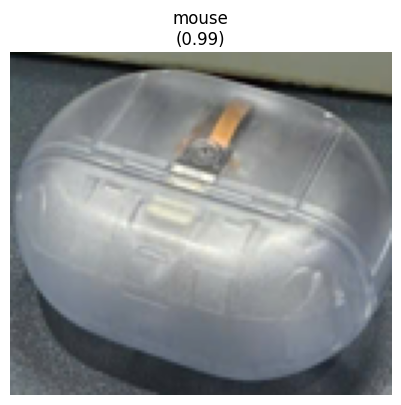

In [188]:
process_image("img_test_15.jpg")


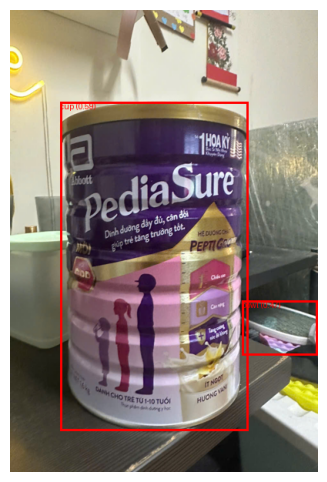

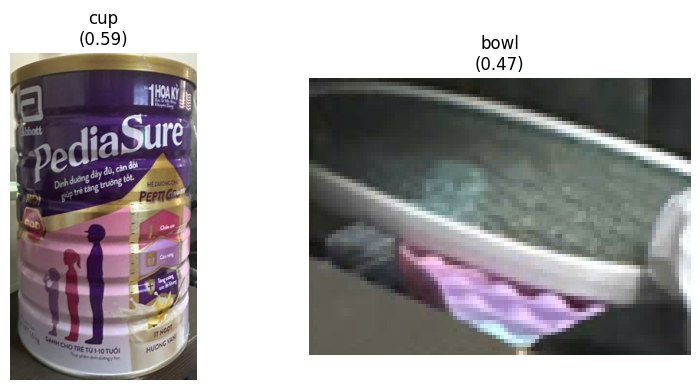

In [171]:
process_image("img_test_2.jpg")

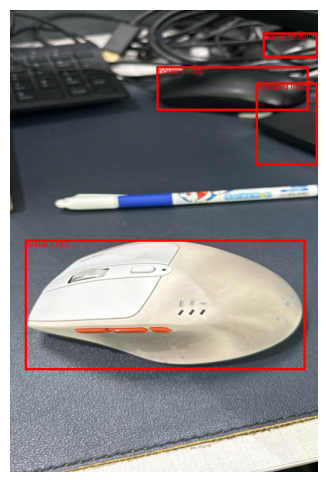

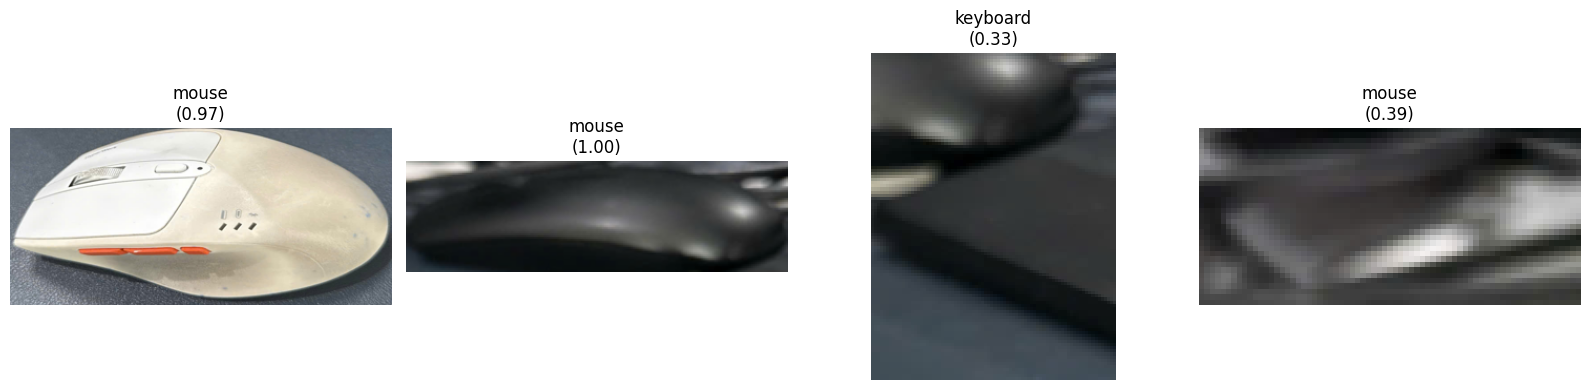

In [172]:
process_image("img_test_3.jpg")

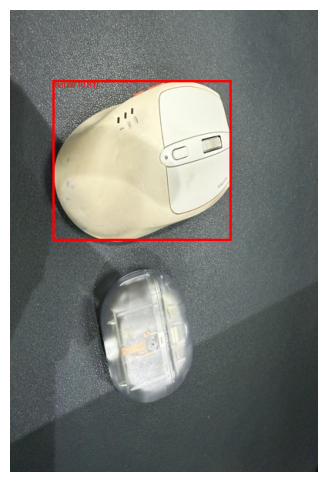

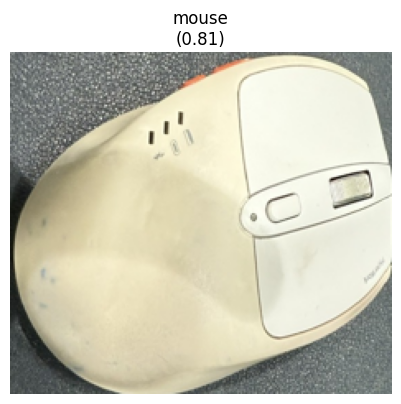

In [173]:
process_image("img_test_4.jpg")

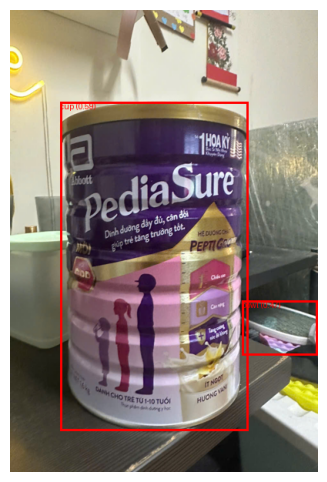

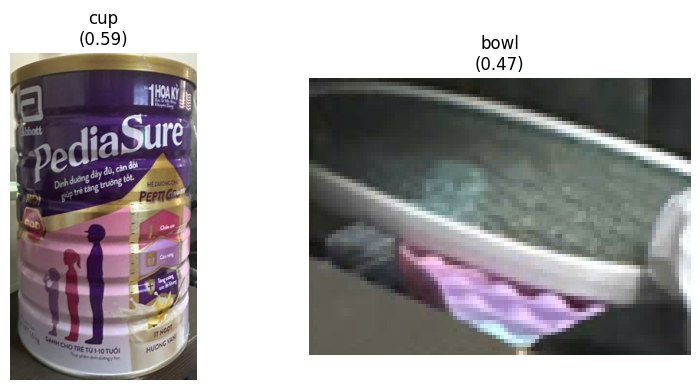

In [174]:
process_image("img_test_5.jpg")

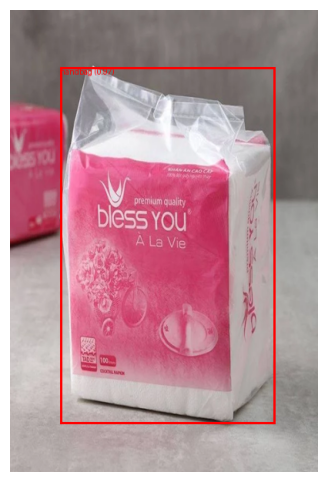

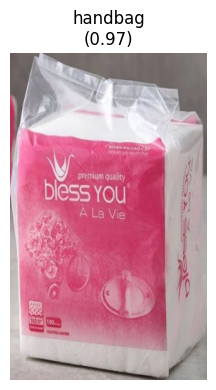

In [175]:
process_image("img_test_6.webp")

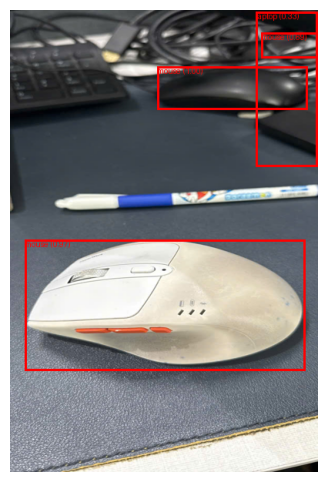

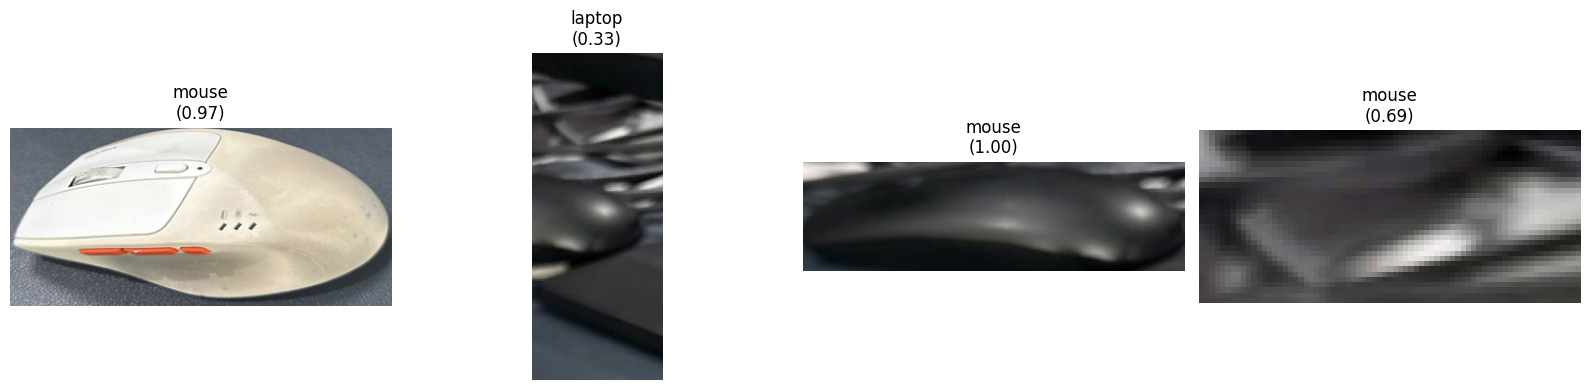

In [176]:
process_image("img_test_7.jpg")

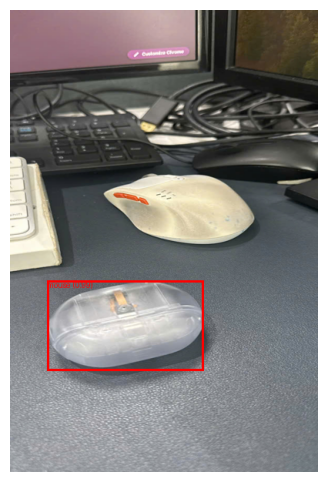

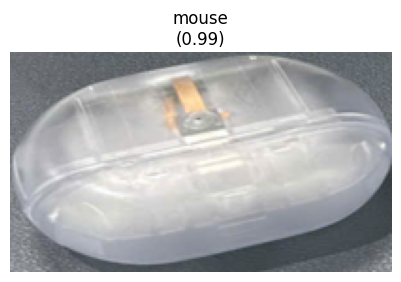

In [177]:
process_image("img_test_8.jpg")

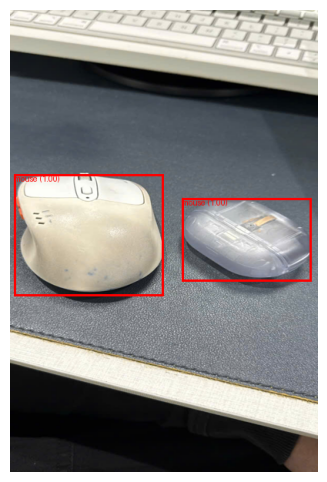

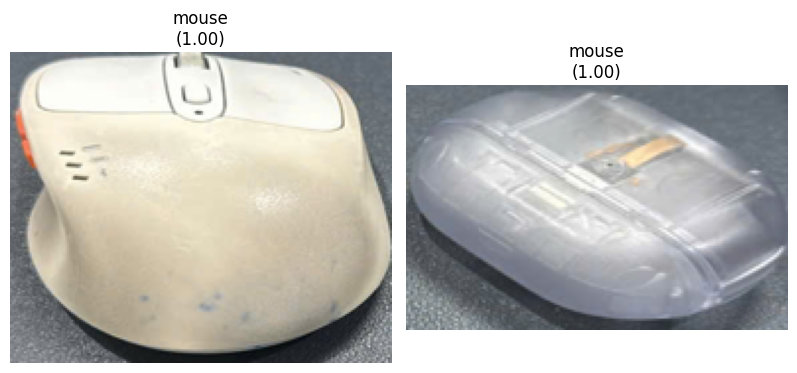

In [178]:
process_image("img_test_9.jpg")

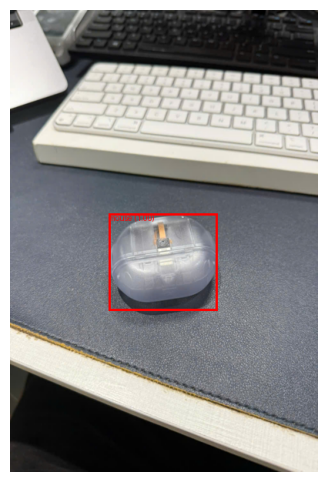

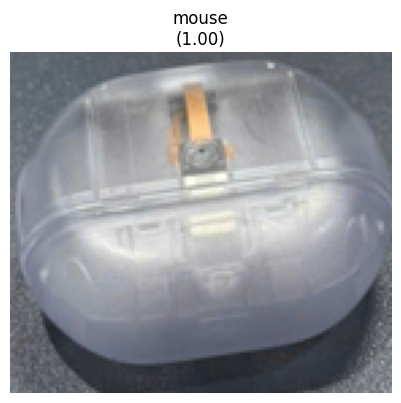

In [179]:
process_image("img_test_10.jpg")